<a href="https://colab.research.google.com/github/Nbassey01/MLOps/blob/main/TourismPackage_Prediction_Notebook_AML_and_MLOps_Project_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement

## **Business Context**

"Visit with Us," a leading travel company, is revolutionizing the tourism industry by leveraging data-driven strategies to optimize operations and customer engagement. While introducing a new package offering, such as the Wellness Tourism Package, the company faces challenges in targeting the right customers efficiently. The manual approach to identifying potential customers is inconsistent, time-consuming, and prone to errors, leading to missed opportunities and suboptimal campaign performance.

To address these issues, the company aims to implement a scalable and automated system that integrates customer data, predicts potential buyers, and enhances decision-making for marketing strategies. By utilizing an MLOps pipeline, the company seeks to achieve seamless integration of data preprocessing, model development, deployment, and CI/CD practices for continuous improvement. This system will ensure efficient targeting of customers, timely updates to the predictive model, and adaptation to evolving customer behaviors, ultimately driving growth and customer satisfaction.


## **Objective**

As an MLOps Engineer at "Visit with Us," your responsibility is to design and deploy an MLOps pipeline on GitHub to automate the end-to-end workflow for predicting customer purchases. The primary objective is to build a model that predicts whether a customer will purchase the newly introduced Wellness Tourism Package before contacting them. The pipeline will include data cleaning, preprocessing, transformation, model building, training, evaluation, and deployment, ensuring consistent performance and scalability. By leveraging GitHub Actions for CI/CD integration, the system will enable automated updates, streamline model deployment, and improve operational efficiency. This robust predictive solution will empower policymakers to make data-driven decisions, enhance marketing strategies, and effectively target potential customers, thereby driving customer acquisition and business growth.

## **Data Description**

The dataset contains customer and interaction data that serve as key attributes for predicting the likelihood of purchasing the Wellness Tourism Package. The detailed attributes are:

**Customer Details**
- **CustomerID:** Unique identifier for each customer.
- **ProdTaken:** Target variable indicating whether the customer has purchased a package (0: No, 1: Yes).
- **Age:** Age of the customer.
- **TypeofContact:** The method by which the customer was contacted (Company Invited or Self Inquiry).
- **CityTier:** The city category based on development, population, and living standards (Tier 1 > Tier 2 > Tier 3).
- **Occupation:** Customer's occupation (e.g., Salaried, Freelancer).
- **Gender:** Gender of the customer (Male, Female).
- **NumberOfPersonVisiting:** Total number of people accompanying the customer on the trip.
- **PreferredPropertyStar:** Preferred hotel rating by the customer.
- **MaritalStatus:** Marital status of the customer (Single, Married, Divorced).
- **NumberOfTrips:** Average number of trips the customer takes annually.
- **Passport:** Whether the customer holds a valid passport (0: No, 1: Yes).
- **OwnCar:** Whether the customer owns a car (0: No, 1: Yes).
- **NumberOfChildrenVisiting:** Number of children below age 5 accompanying the customer.
- **Designation:** Customer's designation in their current organization.
- **MonthlyIncome:** Gross monthly income of the customer.

**Customer Interaction Data**
- **PitchSatisfactionScore:** Score indicating the customer's satisfaction with the sales pitch.
- **ProductPitched:** The type of product pitched to the customer.
- **NumberOfFollowups:** Total number of follow-ups by the salesperson after the sales pitch.-
- **DurationOfPitch:** Duration of the sales pitch delivered to the customer.


# Installing and Importing Necessary Libraries

In [266]:
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scipy==1.11.4 -q --user  # Installing the libraries with the specified version.
!pip install -q PyGithub==2.9.1     # To get github packages installed
!pip install mlflow==3.0.1 pyngrok==7.2.12 -q    # To get ngrok packages installed

  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [267]:
# from google.colab import drive
# drive.mount('/content/drive')

In [268]:
# To Manipulate and Analyze Data
import numpy as np
import pandas as pd

# To Visualize Data
from matplotlib import pyplot as plt
import seaborn as sns

## Reading the Data into a DataFrame

In [269]:
# To load dataset
tourism_purchase = pd.read_csv("sample_data/tourism.csv")

## Data Overview

In [270]:
# To Create a copy of the dataset
tourism_purchase = tourism_purchase.copy()

## Displaying the first and last few rows of the dataset

In [271]:
# To view the first 5 rows of the dataset
tourism_purchase.head(5)

,Unnamed: 0,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,...,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,...,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,...,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,...,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,...,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,5,200005,0,32.0,Company Invited,1,8.0,Salaried,Male,3,...,Basic,3.0,Single,1.0,0,5,1,1.0,Executive,18068.0


In [272]:
# To view the last 5 rows of the dataset
tourism_purchase.tail(5)

,Unnamed: 0,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,...,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
4123,4883,204883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,3,...,Deluxe,4.0,Unmarried,2.0,1,1,1,1.0,Manager,26576.0
4124,4884,204884,1,28.0,Company Invited,1,31.0,Salaried,Male,4,...,Basic,3.0,Single,3.0,1,3,1,2.0,Executive,21212.0
4125,4885,204885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4,...,Standard,4.0,Married,7.0,0,1,1,3.0,Senior Manager,31820.0
4126,4886,204886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,3,...,Basic,3.0,Single,3.0,0,5,0,2.0,Executive,20289.0
4127,4887,204887,1,36.0,Self Enquiry,1,14.0,Salaried,Male,4,...,Basic,4.0,Unmarried,3.0,1,3,1,2.0,Executive,24041.0


## Understanding the shape of the data

In [273]:
# To check how big is the data
tourism_purchase.shape

(4128, 21)

### **Observations:**


*   Total number of rows - 4128
*   Total number of columns - 21



## Checking the Attributes of Data

In [274]:
# Checking for attributes of the data
tourism_purchase.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4128 entries, 0 to 4127
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                4128 non-null   int64  
 1   CustomerID                4128 non-null   int64  
 2   ProdTaken                 4128 non-null   int64  
 3   Age                       4128 non-null   float64
 4   TypeofContact             4128 non-null   object 
 5   CityTier                  4128 non-null   int64  
 6   DurationOfPitch           4128 non-null   float64
 7   Occupation                4128 non-null   object 
 8   Gender                    4128 non-null   object 
 9   NumberOfPersonVisiting    4128 non-null   int64  
 10  NumberOfFollowups         4128 non-null   float64
 11  ProductPitched            4128 non-null   object 
 12  PreferredPropertyStar     4128 non-null   float64
 13  MaritalStatus             4128 non-null   object 
 14  NumberOf

### **Observations:**

total of 4128 observations in all.
*   Unnamed, CustomerID, ProdTaken, CityTier, NumberOfPersonVisiting, Passport, PitchSatisfactionScore, and OwnCar columns are interger types.  
*   TypeofContact,  Occupation, Gender, MaritalStatus, Designation are Object columns
*   Age, DurationOfPitch, NumberOfFollowups, PreferredPropertyStar, NumberOfTrips, NumberOfChildrenVisiting, and MonthlyIncome are float types





## Checking the numerical statistical summary of the data

In [275]:
# To Check the statistical summary of the data
tourism_purchase.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,4128.0,2527.763808,1409.439133,0.0,1320.75,2603.5,3748.25,4887.0
CustomerID,4128.0,202527.763808,1409.439133,200000.0,201320.75,202603.5,203748.25,204887.0
ProdTaken,4128.0,0.193072,0.394757,0.0,0.00,0.0,0.00,1.0
Age,4128.0,37.231831,9.174521,18.0,31.00,36.0,43.00,61.0
CityTier,4128.0,1.663275,0.920640,1.0,1.00,1.0,3.00,3.0
DurationOfPitch,4128.0,15.584787,8.398142,5.0,9.00,14.0,20.00,127.0
NumberOfPersonVisiting,4128.0,2.949370,0.718818,1.0,2.00,3.0,3.00,5.0
NumberOfFollowups,4128.0,3.741521,1.006786,1.0,3.00,4.0,4.00,6.0
PreferredPropertyStar,4128.0,3.578488,0.795031,3.0,3.00,3.0,4.00,5.0
NumberOfTrips,4128.0,3.295300,1.856300,1.0,2.00,3.0,4.00,22.0


### **Observations:**



*   Averrage customer Age was 37yrs while the oldest was 61yrs old.
*   DurationOfPitch average was 15.5 with max of 127.
*   Average MonthlyIncome of customers was 23178.46 and maximum income was 98678.0 with standard deviation of 4506.61.
*   Mean hotekl rating by customer was 3.5 and maximum rating by customer was 5.0.
* Adult visiting average was 2.9 with children 1.2 wile maximum of adult was 5 and max number of children visiting was 3.
* Annual average trip a customer makes was 3.2 with max of 22.
* Max satifaction score was 5.0 with an average 3.0 and standard deviation of 1.3.


## Checking the categorical statistical summary

In [276]:
# To Check the categorical summary of the data
tourism_purchase.describe(exclude=[np.number]).T

,count,unique,top,freq
TypeofContact,4128,2,Self Enquiry,2918
Occupation,4128,4,Salaried,1999
Gender,4128,3,Male,2463
ProductPitched,4128,5,Basic,1615
MaritalStatus,4128,4,Married,1990
Designation,4128,5,Executive,1615


## Checking for duplicated values

In [277]:
# To check for duplicated values
tourism_purchase.duplicated().sum()

np.int64(0)

### **Observations:**

* There are no duplicated values in the dataset

## Checking for missing values

In [278]:
# To check for missing values
tourism_purchase.isnull().sum()

,0
Unnamed: 0,0
CustomerID,0
ProdTaken,0
Age,0
TypeofContact,0
CityTier,0
DurationOfPitch,0
Occupation,0
Gender,0
NumberOfPersonVisiting,0


### **Observations:**

* There are no missing values in the dataset

## Univariate Analysis

### Observations On Age

In [279]:
# To check for counts of customer Age
tourism_purchase['Age'].value_counts()

,count
Age,
36.0,215
35.0,214
31.0,188
30.0,188
34.0,187
33.0,178
37.0,177
32.0,177
38.0,171


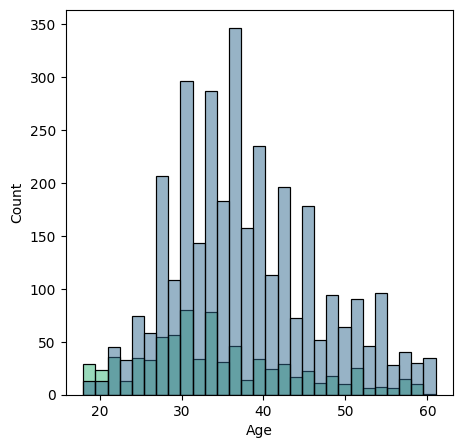

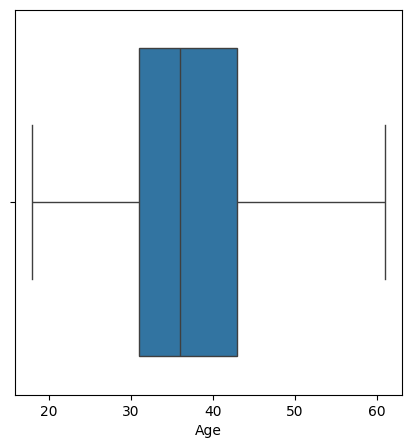

In [280]:
# To check for distributions on Age
plt.figure(figsize=(5, 5))
sns.histplot(data=tourism_purchase,x='Age',hue='ProdTaken', palette='viridis', legend=False)
plt.show()
plt.figure(figsize=(5, 5))
sns.boxplot(data=tourism_purchase,x='Age')
plt.show()

### **Observations:**
* Age column appears ti be slightly left skewed with no outliers.
* A count on customer Age shows those who are 35 and 36yrs were 214 and 215 with 188 each for 30 - 31yrs with the least count of 9 customers for those whose age are 61.
* A distribution of customers whose age are 30 to 45yrs are more than compared to the number in other age category.

### Observations On TypeofContact

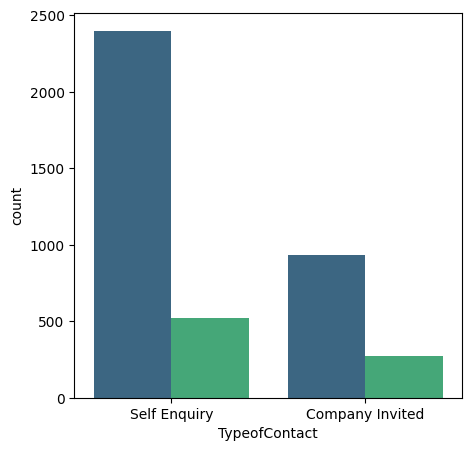

In [281]:
# To check for distribution on TypeofContact
plt.figure(figsize=(5, 5))
sns.countplot(data=tourism_purchase,x='TypeofContact',hue='ProdTaken', palette='viridis', legend=False)
plt.show()

### **Observations:**
* A distribution count of about 1000 customers were invited by Visit with us company, about 250 would likely purchase the tourism package
* A count of over 2300 customers made Self Enquiry of Visit with Us company and about 500 custoner may likely purchase the package

### Observations On CityTier

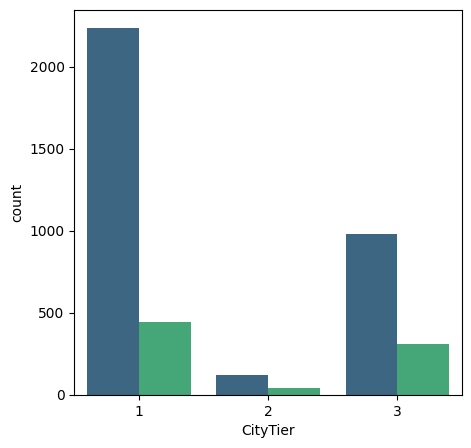

In [282]:
# To check for distribution on CityTier
plt.figure(figsize=(5, 5))
sns.countplot(data=tourism_purchase,x='CityTier',hue='ProdTaken', palette='viridis', legend=False)
plt.show()

### **Observations:**
* About 2300 customer living standard fall in Tier-1 but thise who would buy the tourism pack are slightly below 500.
* 1000 customers are in Tier-3 category and about 300 of them would likely purchase the pack while those of Tier-2 are below 200.


## Observations On ProdTaken

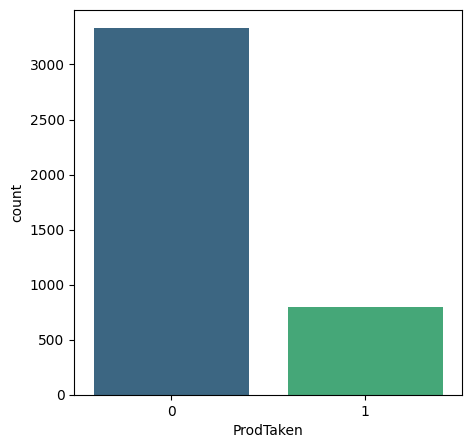

In [283]:
# To check for distribution on ProdTaken
plt.figure(figsize=(5, 5))
sns.countplot(data=tourism_purchase,x='ProdTaken',hue='ProdTaken', palette='viridis', legend=False)
plt.show()

### **Observations:**
* About 3400 customer have not made purchase of the package while 800 customers has purchased tourism package

## Observation On Occupation

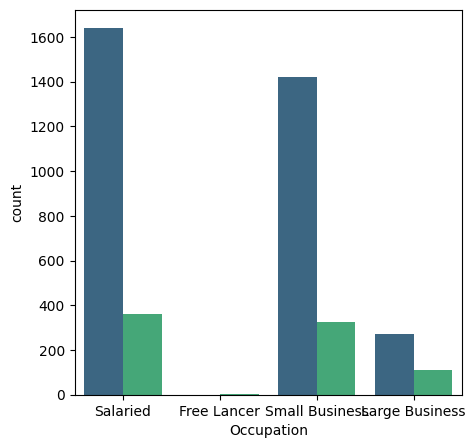

In [284]:
# To check for distribution on Occupation
plt.figure(figsize=(5, 5))
sns.countplot(data=tourism_purchase,x='Occupation',hue='ProdTaken', palette='viridis', legend=False)
plt.show()

### **Observations:**
* Close to 400 salary earners from 1700 customers in that category purchased package.
* About 350 customer of Small Business onwers purchased tourism package while 1400 did not.
* Large Business owners had count of about 300 customers who didnt buy while 100 bought the tourism package.
*FreeLancer had no count of those who buy under the category

## Observation On Gender

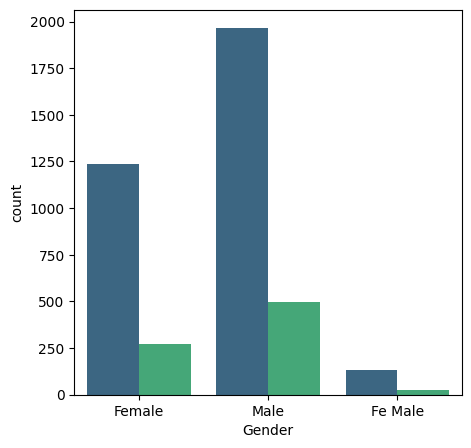

In [285]:
# To check for distribution on Gender
plt.figure(figsize=(5, 5))
sns.countplot(data=tourism_purchase,x='Gender',hue='ProdTaken', palette='viridis', legend=False)
plt.show()

### **Observations:**
* A total count of 1250 female recorder while only 250 purchased the package
* Total of 2000 customers were male and only 500 made purchase.  

## Observation On NumberOfPersonVisiting

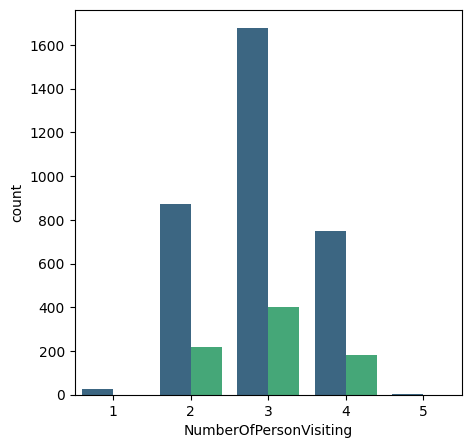

In [286]:
# To check for distribution on NumberOfPersonVisiting
plt.figure(figsize=(5, 5))
sns.countplot(data=tourism_purchase,x='NumberOfPersonVisiting',hue='ProdTaken', palette='viridis', legend=False)
plt.show()

### **observations:**
* About 400 out of 1800 customer who had 3 people each accompanied them buy package.
* 200 customers out of 900 that came with 2 people each made purchases of the package while close to 200 customers who came with 4 people that accompanied them also purchased the package from 700 recorded.

## Observation On PreferredPropertyStar

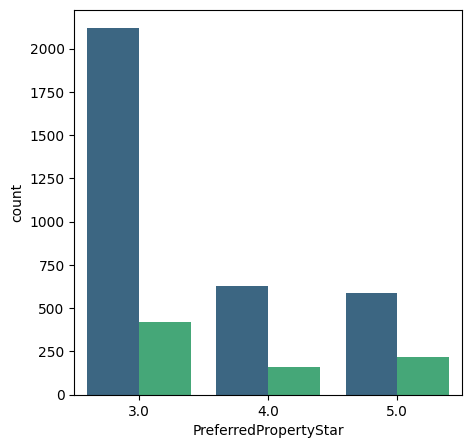

In [287]:
# To check for distribution on PreferredPropertyStar
plt.figure(figsize=(5, 5))
sns.countplot(data=tourism_purchase,x='PreferredPropertyStar',hue='ProdTaken', palette='viridis', legend=False)
plt.show()

### **Observations:**
* over 2400 customer gave thier rating 3.0 and only about 400 of them purchased the package.
*Among 600 customers that rated 4.0, a number who purchase the tourism package was about 200.
* Total of 230 customers purchase the package from 600 who who gave rating of 5.0

## Observation On MaritalStatus

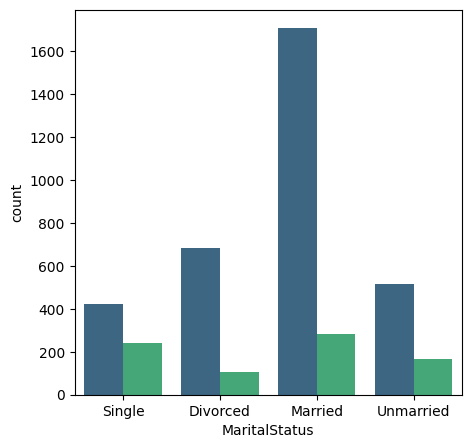

In [288]:
# To check for distribution on MaritalStatus
plt.figure(figsize=(5, 5))
sns.countplot(data=tourism_purchase,x='MaritalStatus',hue='ProdTaken', palette='viridis', legend=False)
plt.show()

### **Observations:**
* Among the 400 single, those who prurchased the packae were slighty above 200.
* About 300 out of over 1700 married customers made purchase while 200 unmarried ones out of 500 bought the tourism packages
* Divorced customers had less than 150 from a count of about 700 wh also buy the package.   

## Observation On NumberOfTrips

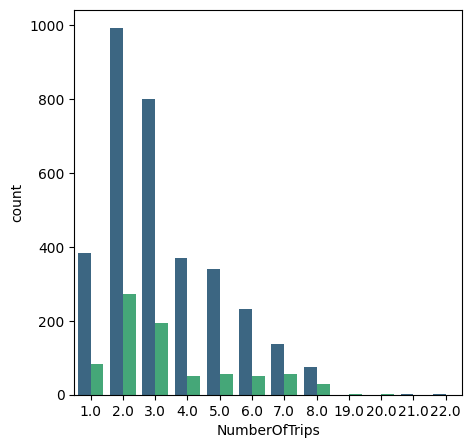

In [289]:
# To check for distribution on NumberOfTrips
plt.figure(figsize=(5, 5))
sns.countplot(data=tourism_purchase,x='NumberOfTrips',hue='ProdTaken', palette='viridis', legend=False)
plt.show()

### **Observations:**
* Over 800 to 1000 customers had an average trip of 2.0 to 3.0 annualy, about 200 to 300 of the had bought the package.
* 50 to 100 customers that buy tourism packages from 400 customers had made 4.0 and 1.0 trips.
* Customers who made 5.0 6.0 and 7.0 trips where about 450, 250 and 150, these number had less than 100 in each trip category who bought the package  

## Observation On Passport

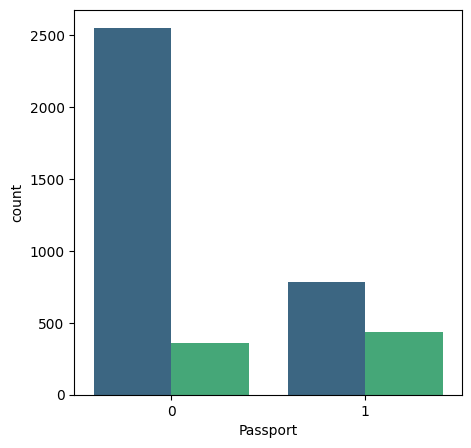

In [290]:
# To check for distribution on Passport
plt.figure(figsize=(5, 5))
sns.countplot(data=tourism_purchase,x='Passport',hue='ProdTaken', palette='viridis', legend=False)
plt.show()

### **Observations:**
* Among customers with passports, about 400 purchased tourism package while about 700 didnt but have passports.
* 300 cusotmers out of 2500 who dod not have passports bought tourism packages.

## Observation On OwnCar

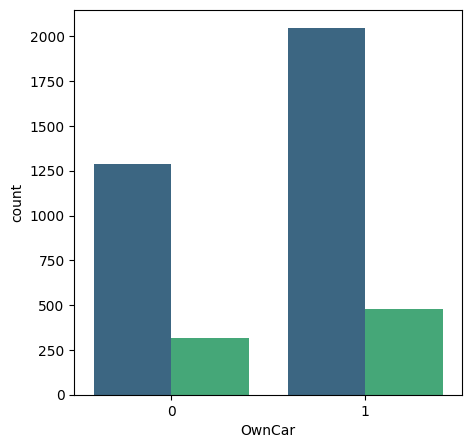

In [291]:
# To check for distribution on OwnCar
plt.figure(figsize=(5, 5))
sns.countplot(data=tourism_purchase,x='OwnCar',hue='ProdTaken', palette='viridis', legend=False)
plt.show()

### **Observations:**
* A total of 1250 customers do not own car, about 300 of them had bought the package.
* Total of 2000 customers own a car and 500 of them had purchased the package.

## Observations On NumberOfChildrenVisiting

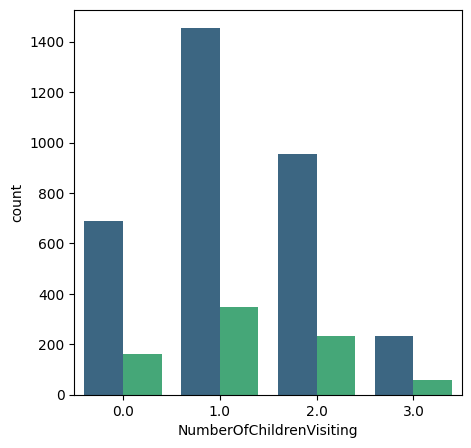

In [292]:
# To check for distribution on NumberOfChildrenVisiting
plt.figure(figsize=(5, 5))
sns.countplot(data=tourism_purchase,x='NumberOfChildrenVisiting',hue='ProdTaken', palette='viridis', legend=False)
plt.show()

### **Observations:**
* About 350 customer out of 1500 that came with a children below 1year bought the package.
* About 250 customers bought the package from  total of 950 that came with children below 2yrs.
* About 190 customer that came with children below 1yr purchased the package from a total of 700.
* 250 customers who came with children that are below 3yrs old, less than 100 purchased the package.


## Observations On Designation

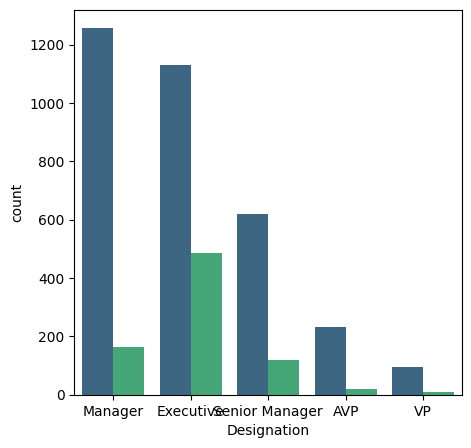

In [293]:
# To check for distribution on Designation
plt.figure(figsize=(5, 5))
sns.countplot(data=tourism_purchase,x='Designation',hue='ProdTaken', palette='viridis', legend=False)
plt.show()

### **Observations:**
* Over customers who are managers designate, less thann 200 purchased the tourism package.
* Among over 1100 Executive that came, about 500 had bought the package.
* 600 senior managers that came, less than 150 bought the package.
* over 200 AVP customers who came, lessthan 50 bought while from less than 200 VP customers who came, less than 30 had purchased the package.   

## Observations On MonthlyIncome

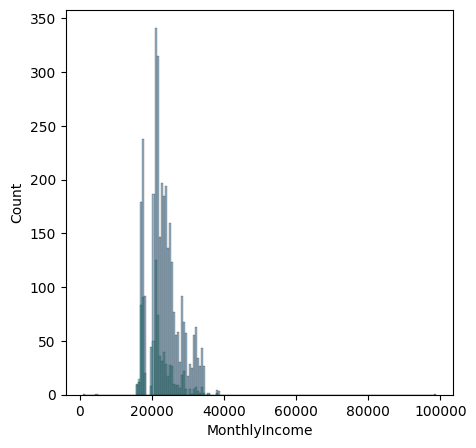

In [294]:
# To check for distribution on MonthlyIncome
plt.figure(figsize=(5, 5))
sns.histplot(data=tourism_purchase,x='MonthlyIncome',hue='ProdTaken', palette='viridis', legend=False)
plt.show()

### **Observations:**
* Customers who purchased the most package had monthly income between 20 to 40.

## Observations on PitchSatisfactionScore

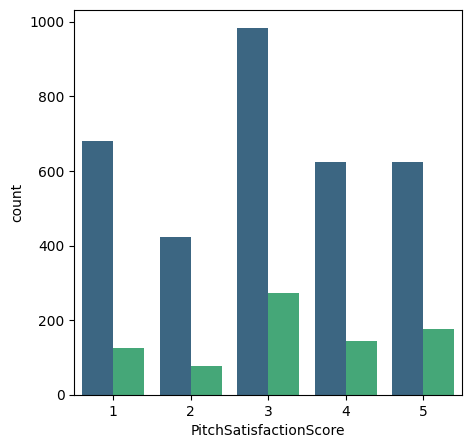

In [295]:
# To check for distribution on PitchSatisfactionScore
plt.figure(figsize=(5, 5))
sns.countplot(data=tourism_purchase,x='PitchSatisfactionScore',hue='ProdTaken', palette='viridis', legend=False)
plt.show()

### **Observations:**
* A total of 1000 customers got  pitch satifaction of 3, a small proportion of less than 400 purchsed the tourism package.
* A total of 600 customers with 4 and 5 pitch satisfactiion score across, less than 200 had purchased the package.
* A total of 650 custoners that had 1 satisfaction score, about 150 had bought the package.  

## Observations On ProductPitched

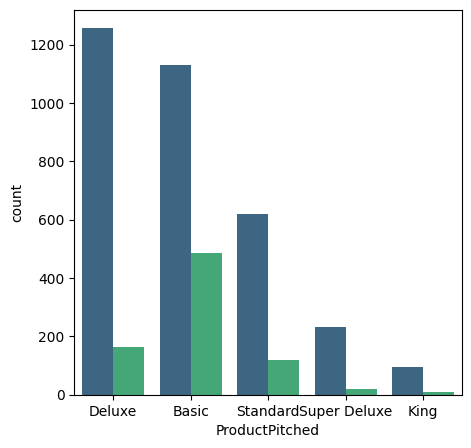

In [296]:
# To check for distribution on ProductPitched
plt.figure(figsize=(5, 5))
sns.countplot(data=tourism_purchase,x='ProductPitched',hue='ProdTaken', palette='viridis', legend=False)
plt.show()

### **Observations:**
* Over 1200 customner that had deluxe product types, less than 200 got package.
* Out of 1100 customer of Basic product type, about 500 customer had bouhgt the tourism package.
* A total of 600 customers with standard product type, less than 200 purchased the package.
* Customers who had Super deluxe and king product types, a small portion of about 50 less had purchased the package across.

## Observations On NumberOfFollowups

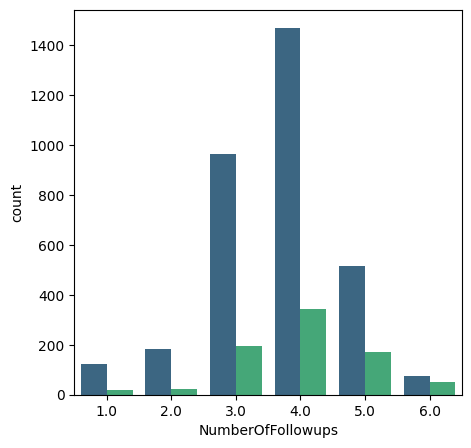

In [297]:
# To check for distribution on NumberOfFollowups
plt.figure(figsize=(5, 5))
sns.countplot(data=tourism_purchase,x='NumberOfFollowups',hue='ProdTaken', palette='viridis', legend=False)
plt.show()

### **Observations:**
* Among over 1400 custmer with 4 followups, abut 350 had bought the package.
* Less than 1000 customers with 3 followups, only 200 had gotten the package.
* Total of 500 customer with 5 followups, less than 200 purchased the package.
* Less than 200 Customers with 2 followup, 1 followups and 6 followups, less than 100 customers bought the package across.  

## Observations On DurationOfPitch

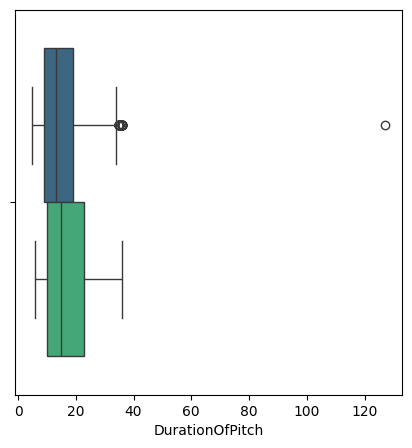

In [298]:
# To check for distribution on DurationOfPitch
plt.figure(figsize=(5, 5))
sns.boxplot(data=tourism_purchase,x='DurationOfPitch',hue='ProdTaken', palette='viridis', legend=False)
plt.show()

### **Observations:**
* Duration Of Pitch is left skewed and with outliers
* Most customers who participated got 40 minute max of sales pitch delivered.  

## Bivariate Analysis

Let us draw a correlation heat map to check for relationships between the columns

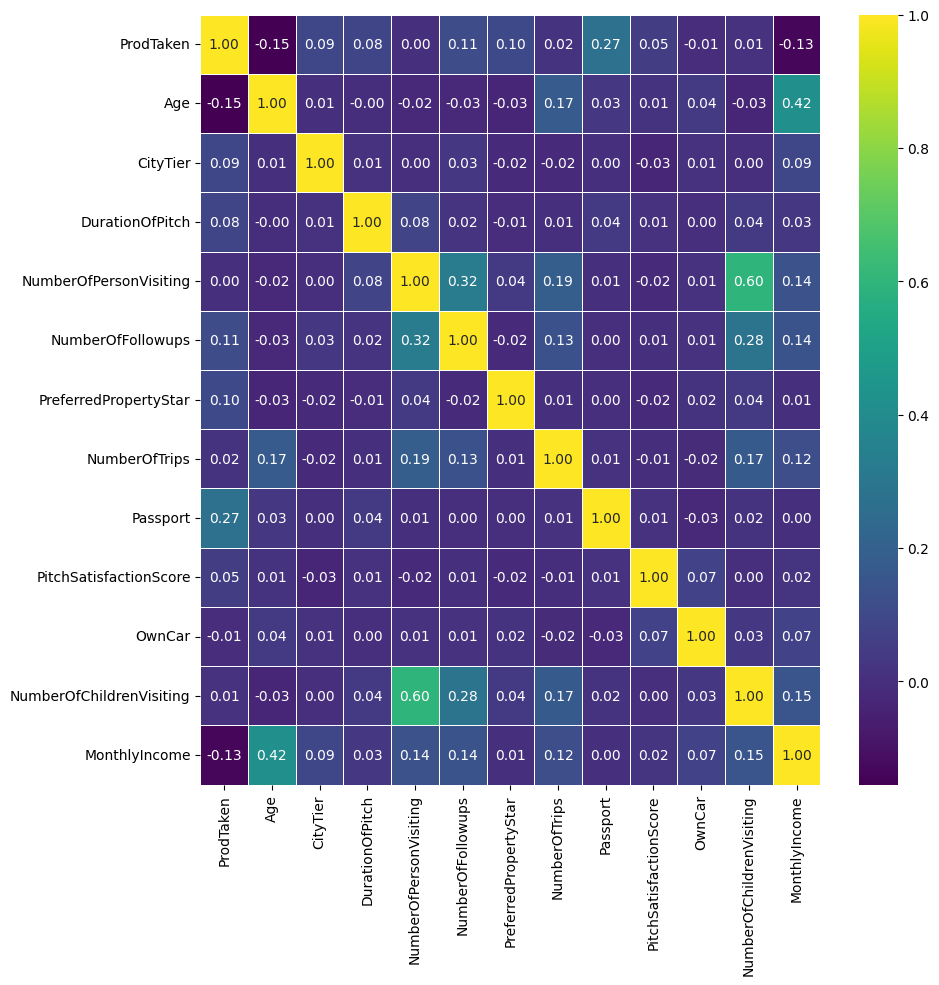

In [299]:
import numpy as np
# To Compute the correlation matrix
# To Select only numerical columns for correlation calculation
numeric_df = tourism_purchase.select_dtypes(include=[np.number])

# To Drop 'Unnamed: 0' and 'CustomerID' as they are identifiers and not meaningful for correlation
if 'Unnamed: 0' in numeric_df.columns:
    numeric_df = numeric_df.drop(columns=['Unnamed: 0'])
if 'CustomerID' in numeric_df.columns:
    numeric_df = numeric_df.drop(columns=['CustomerID'])

corr_matrix = numeric_df.corr()

# To Set up the figure
plt.figure(figsize=(10, 10))

# To draw the correlation heatmap
sns.heatmap(corr_matrix, annot=True, cmap="viridis", fmt=".2f", linewidths=0.5)

# To Show the map
plt.show()

### **Observations:**
* There is a high correlation of 0.60 between Number of children visiting vs Number of Persons Visiting which means cusatomers prefered to bring thier children along.
* There is a significant correlations in Age vs MonthlyIncome which indicates the older the more income and likely older people purchased more package then the young ones.
*Number of person visiting column was correlated with Number of Followups and slightly also correlated with Number of followups.
* A slight correlations was recorded between Passport column and ProdTaken.
* Number of person visiting correlated with Number of trips.
* Number of trip slightly correlated with Age by 0.17

Let us proceed to build our MLOps Pipeline

In [300]:
import os
from github import Github, GithubException

from pyngrok import ngrok
import subprocess
import mlflow

import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

### **Observations**


*   We need to import the necessary libraries to be able to execute our project like above.



# Configuration

In [301]:
# Edit these three values, then run every cell top to bottom. Nbassey01/Machine_Failure_Prediction
GITHUB_USERNAME  ="Nbassey01" # Your GitHub username
REPO_NAME        ="Tourism-Pack-Purchase-Prediction" # Repositiory name
COLAB_SECRET_NAME = "Github_clss_token_4" # Name of the secret in colabs

REPO  = f"{GITHUB_USERNAME}/{REPO_NAME}"
BRANCH = "main"

In [302]:
# Make the token available to both PyGithub and the gh CLI
import os
from google.colab import userdata
os.environ["GH_TOKEN"] = userdata.get(COLAB_SECRET_NAME)
print("Token loaded.")

Token loaded.


# Model Building

In [303]:
# Create a master folder to keep all files created when executing the below code cells
import os
os.makedirs("tourism_purchase", exist_ok=True)

The above code snippet is to create our Master folder for storage

In [304]:
os.makedirs("tourism_purchase/data", exist_ok=True)

We then create a folder for our data.

### Once the data folder created after executing the above cell, we further upload the tourism.csv in to the folder

In [305]:
# Create a folder for storing the model building files
os.makedirs("tourism_purchase/model_building", exist_ok=True)

## Data Registration

In [306]:
%%writefile tourism_purchase/model_building/data_register.py
import pandas as pd

RAW_PATH = "tourism_purchase/data/tourism.csv"

# Load the raw dataset
df = pd.read_csv(RAW_PATH)

# Validate that the expected columns are present before registering it
expected_columns = [
    "CustomerID", "ProdTaken", "Age", "TypeofContact", "CityTier",
    "DurationOfPitch", "Occupation", "Gender", "NumberOfPersonVisiting",
    "NumberOfFollowups", "ProductPitched", "PreferredPropertyStar",
    "MaritalStatus", "NumberOfTrips", "Passport", "PitchSatisfactionScore",
    "OwnCar", "NumberOfChildrenVisiting", "Designation", "MonthlyIncome",
]
missing = [c for c in expected_columns if c not in df.columns]
if missing:
    raise ValueError(f"Dataset is missing expected columns: {missing}")

print("Dataset registered successfully.")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("Columns:", list(df.columns))
print("ProdTaken distribution:")
print(df["ProdTaken"].value_counts())

Overwriting tourism_purchase/model_building/data_register.py


## Data Preparation

In [307]:
%%writefile tourism_purchase/model_building/prep.py
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("tourism_purchase/data/tourism.csv")
df.drop(columns=["CustomerID"], inplace=True)

# NOTE: categorical columns are intentionally left as raw strings.
# The training pipeline one-hot-encodes them, and the Streamlit app also sends
# raw category values. Encoding them here (e.g. LabelEncoder) would make training
# and serving use different representations, silently breaking predictions.

target = "ProdTaken"  # to set the name of the column to predict (whether customer purchased the package), 1 if the customer purchased the package, else 0
X = df.drop(columns=[target])
y = df[target]

# Perform train-test split
Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Xtrain.to_csv("Xtrain.csv", index=False)
Xtest.to_csv("Xtest.csv", index=False)
ytrain.to_csv("ytrain.csv", index=False)
ytest.to_csv("ytest.csv", index=False)

print("Data prepared: train/test splits written.")
print("ProdTaken distribution in train:")
print(ytrain.value_counts())

Overwriting tourism_purchase/model_building/prep.py


## Model Training and Registration with Experimentation Tracking

In [308]:
from pyngrok import ngrok
import subprocess
import mlflow

# Set your auth token here
ngrok.set_auth_token("3Ib8atF5GUJipLQquNqNYc5OFMS_2mjFyZByfNsqaYyZnxFvU")

# Start MLflow UI on port 5000
process = subprocess.Popen(["mlflow", "ui", "--port", "5000"])

# Create public tunnel
public_url = ngrok.connect(5000).public_url
print("MLflow UI is available at:", public_url)

MLflow UI is available at: https://askew-synopsis-antidote.ngrok-free.dev


In [309]:
# Set the tracking URL for MLflow
mlflow.set_tracking_uri(public_url)

# Set the name for the experiment
mlflow.set_experiment("mlops_experiment3")

<Experiment: artifact_location='mlflow-artifacts:/224722448087730365', creation_time=1789621347336, experiment_id='224722448087730365', last_update_time=1789621347336, lifecycle_stage='active', name='mlops_experiment3', tags={}>

## Experimentation and Tracking (Production Environment)

In [310]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report # Import classification_report
import mlflow

df = pd.read_csv("tourism_purchase/data/tourism.csv")
print("Dataset loaded successfully.")

df = df.drop(columns=["CustomerID"])

# NOTE: categorical columns are left as raw strings; they are one-hot-encoded
# inside the pipeline below, so training and serving stay consistent.

target_col ="ProdTaken"  # The code to set the name of the column to predict (same as in prep.py)
X = df.drop(columns=[target_col])
y = df[target_col]

Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_features = [
    "Age", "DurationOfPitch", "NumberOfPersonVisiting", "NumberOfFollowups", "CityTier", "NumberOfTrips",
    "PitchSatisfactionScore", "NumberOfChildrenVisiting", "MonthlyIncome", "PreferredPropertyStar", "Passport", "OwnCar"

]   # To list all numerical feature names (same as in prep.py)

categorical_features = [
    "TypeofContact", "Occupation", "Gender", "MaritalStatus", "Designation", "ProductPitched"

]   # To list all categorical feature names (same as in prep.py)

# Handle class imbalance
class_weight = ytrain.value_counts()[0] / ytrain.value_counts()[1]

# Define the preprocessing steps
preprocessor = make_column_transformer(
    (StandardScaler(), numeric_features),
    (OneHotEncoder(handle_unknown="ignore"), categorical_features)
)

# Define base XGBoost model
xgb_model = xgb.XGBClassifier(scale_pos_weight=class_weight, random_state=42)

# Define hyperparameter grid
# Setting values for each parameter based on your understanding of XGBoost tuning.
param_grid = {
    'xgbclassifier__n_estimators': [50, 100],        # Number of boosting trees. More trees can improve performance but increase training time.
    'xgbclassifier__max_depth': [3, 5],           # Maximum depth of each tree. Higher values increase model complexity and risk of overfitting.
    'xgbclassifier__colsample_bytree': [0.5, 0.6],    # Fraction of features sampled when building each tree.
    'xgbclassifier__colsample_bylevel': [0.5, 0.6],   # Fraction of features sampled at each tree level.
    'xgbclassifier__learning_rate': [0.05, 0.1],       # Step size used during boosting. Smaller values may improve generalization but require more trees.
    'xgbclassifier__reg_lambda': [0.5, 0.6],          # L2 regularization strength. Higher values help reduce overfitting.
}

# Model pipeline
model_pipeline = make_pipeline(preprocessor, xgb_model)   # To build the model pipeline by chaining preprocessor and xgb_model

with mlflow.start_run():
    # Hyperparameter tuning
    grid_search = GridSearchCV(model_pipeline, param_grid, cv=5, n_jobs=-1)
    grid_search.fit(Xtrain, ytrain)

    # Log all parameter combinations and their mean test scores
    results = grid_search.cv_results_
    for i in range(len(results["params"])):
        param_set = results["params"][i]
        mean_score = results["mean_test_score"][i]
        std_score = results["std_test_score"][i]

        # Log each combination as a separate MLflow run
        with mlflow.start_run(nested=True):
            mlflow.log_params(param_set)
            mlflow.log_metric("mean_test_score", mean_score)
            mlflow.log_metric("std_test_score", std_score)

    # Log best parameters separately in main run
    mlflow.log_params(grid_search.best_params_)

    # Store and evaluate the best model
    best_model = grid_search.best_estimator_

    # Set classification threshold
    # Experiment with different threshold values and observe their impact on
    # precision, recall, F1-score, and overall model performance.
    classification_threshold = 0.45    # To set a classification threshold between 0 and 1. Lower thresholds typically increase recall and decrease precision and vice versa.

    y_pred_train_proba = best_model.predict_proba(Xtrain)[:, 1]
    y_pred_train = (y_pred_train_proba >= classification_threshold).astype(int)

    y_pred_test_proba = best_model.predict_proba(Xtest)[:, 1]
    y_pred_test = (y_pred_test_proba >= classification_threshold).astype(int)

    train_report = classification_report(ytrain, y_pred_train, output_dict=True)
    test_report = classification_report(ytest, y_pred_test, output_dict=True)

    mlflow.log_metrics({
        "train_accuracy": train_report["accuracy"],
        "train_precision": train_report["1"]["precision"],
        "train_recall": train_report["1"]["recall"],
        "train_f1-score": train_report["1"]["f1-score"],
        "test_accuracy": test_report["accuracy"],
        "test_precision": test_report["1"]["precision"],
        "test_recall": test_report["1"]["recall"],
        "test_f1-score": test_report["1"]["f1-score"]
    })

Dataset loaded successfully.
🏃 View run stately-horse-30 at: https://askew-synopsis-antidote.ngrok-free.dev/#/experiments/224722448087730365/runs/2862d382ab6f47a2856b076baffa1127
🧪 View experiment at: https://askew-synopsis-antidote.ngrok-free.dev/#/experiments/224722448087730365
🏃 View run respected-goose-951 at: https://askew-synopsis-antidote.ngrok-free.dev/#/experiments/224722448087730365/runs/252f6ccd34aa49b79e5760459876fa41
🧪 View experiment at: https://askew-synopsis-antidote.ngrok-free.dev/#/experiments/224722448087730365
🏃 View run inquisitive-vole-598 at: https://askew-synopsis-antidote.ngrok-free.dev/#/experiments/224722448087730365/runs/f967790f377c4e72bcdfbb0291cd25f9
🧪 View experiment at: https://askew-synopsis-antidote.ngrok-free.dev/#/experiments/224722448087730365
🏃 View run bouncy-deer-907 at: https://askew-synopsis-antidote.ngrok-free.dev/#/experiments/224722448087730365/runs/72a6d347b5ac454c8476414fc232dca2
🧪 View experiment at: https://askew-synopsis-antidote.ngrok

In [311]:
%%writefile tourism_purchase/model_building/train.py
# for data manipulation
import pandas as pd
# for building the preprocessing and modeling pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# for model serialization and experiment tracking
import joblib
import mlflow

mlflow.set_tracking_uri("http://localhost:5000")   # Code to set the MLflow tracking URI
mlflow.set_experiment("mlops_experiment3")     # Code to set the MLflow experiment name

# Xtrain/Xtest/ytrain/ytest are downloaded from the previous job's artifact
Xtrain = pd.read_csv("Xtrain.csv")
Xtest = pd.read_csv("Xtest.csv")
ytrain = pd.read_csv("ytrain.csv").squeeze()
ytest = pd.read_csv("ytest.csv").squeeze()

numeric_features = [
    "Age", "DurationOfPitch", "NumberOfPersonVisiting", "NumberOfFollowups", "CityTier", "NumberOfTrips",
    "PitchSatisfactionScore", "NumberOfChildrenVisiting", "MonthlyIncome", "PreferredPropertyStar", "Passport", "OwnCar"

]   # To list all numerical feature names (same as in prep.py)

categorical_features =[
    "TypeofContact", "Occupation", "Gender", "MaritalStatus",  "Designation", "ProductPitched"

]   # To list all categorical feature names (same as in prep.py)

#  To Set the class weight to handle class imbalance
class_weight = ytrain.value_counts()[0] / ytrain.value_counts()[1]

# Define the preprocessing steps
preprocessor = make_column_transformer(
    (StandardScaler(), numeric_features),
    (OneHotEncoder(handle_unknown='ignore'), categorical_features)
)
# Define base XGBoost model
xgb_model = xgb.XGBClassifier(scale_pos_weight=class_weight, random_state=42)

# Define hyperparameter grid
# Setting values for each parameters of XGBoost tuning.
param_grid = {
    'xgbclassifier__n_estimators': [50, 100],        # Number of boosting trees. More trees can improve performance but increase training time.
    'xgbclassifier__max_depth': [3, 5],           # Maximum depth of each tree. Higher values increase model complexity and risk of overfitting.
    'xgbclassifier__colsample_bytree': [0.5, 0.6],    # Fraction of features sampled when building each tree.
    'xgbclassifier__colsample_bylevel': [0.5, 0.6],   # Fraction of features sampled at each tree level.
    'xgbclassifier__learning_rate': [0.05, 0.1],       # Step size used during boosting. Smaller values may improve generalization but require more trees.
    'xgbclassifier__reg_lambda': [0.5, 0.6],          # L2 regularization strength. Higher values help reduce overfitting.
}
# Model pipeline
model_pipeline = make_pipeline(preprocessor, xgb_model)   # complete the code to build the model pipeline by chaining preprocessor and xgb_model

#  To Start MLflow run
with mlflow.start_run():
    # Hyperparameter tuning with GridSearchCV
    grid_search = GridSearchCV(model_pipeline, param_grid, cv=5, n_jobs=-1)
    grid_search.fit(Xtrain, ytrain)

    #  To Log every parameter combination tried during the search as a nested run,
    # so all experiments can be compared side by side in the MLflow UI
    results = grid_search.cv_results_
    for i in range(len(results["params"])):
        with mlflow.start_run(nested=True):
            mlflow.log_params(results["params"][i])
            mlflow.log_metric("mean_test_score", results["mean_test_score"][i])
            mlflow.log_metric("std_test_score", results["std_test_score"][i])

    # Log the best hyperparameters in the main run
    mlflow.log_params(grid_search.best_params_)

    # Store the best model
    best_model = grid_search.best_estimator_

    # Set classification threshold
    classification_threshold = 0.45   # Choose a classification threshold between 0 and 1. Lower thresholds typically increase recall and decrease precision and vice versa. Experiment with different values to find the best trade-off.

    # Make predictions on the training and test data
    y_pred_train_proba = best_model.predict_proba(Xtrain)[:, 1]
    y_pred_train = (y_pred_train_proba >= classification_threshold).astype(int)

    y_pred_test_proba = best_model.predict_proba(Xtest)[:, 1]
    y_pred_test = (y_pred_test_proba >= classification_threshold).astype(int)

    # Evaluation
    train_report = classification_report(ytrain, y_pred_train, output_dict=True)
    test_report = classification_report(ytest, y_pred_test, output_dict=True)

    # Log metrics
    mlflow.log_metrics({
        "train_accuracy": train_report['accuracy'],
        "train_precision": train_report['1']['precision'],
        "train_recall": train_report['1']['recall'],
        "train_f1-score": train_report['1']['f1-score'],
        "test_accuracy": test_report['accuracy'],
        "test_precision": test_report['1']['precision'],
        "test_recall": test_report['1']['recall'],
        "test_f1-score": test_report['1']['f1-score']
    })

    # Save next to app.py so the Streamlit app can load it directly, and log
    # it as an MLflow artifact for traceability
    model_path = "tourism_purchase/deployment/best_Tourism_Purchase_Prediction_model_v1.joblib"
    joblib.dump(best_model, model_path)
    mlflow.log_artifact(model_path, artifact_path="model")
    print(f"Model saved to {model_path}")


Overwriting tourism_purchase/model_building/train.py


# Deployment

## Dockerfile

In [312]:
os.makedirs("tourism_purchase/deployment", exist_ok=True)

## Streamlit App

Please ensure that the web app script is named `app.py`.

In [313]:
%%writefile tourism_purchase/deployment/app.py
import os
import streamlit as st
import pandas as pd
import joblib

#  To Load the model committed by the pipeline (sits next to this file)
model_path = os.path.join(os.path.dirname(__file__), "best_Tourism_Purchase_Prediction_model_v1.joblib")
model = joblib.load(model_path)

# Streamlit UI for Tourism Package Prediction
st.title("Tourism Package Prediction")
st.write("Fill the customer details below to predict if they'll purchase a travel package")

# Collect user input
Age = st.slider("Age", 18, 70, 30)
TypeofContact = st.selectbox("Type of Contact", ["Self Enquiry", "Company Invited"])
CityTier = st.selectbox("City Tier", [1, 2, 3])
DurationOfPitch = st.slider("Duration of Pitch (mins)", 0, 100, 15)
Occupation = st.selectbox("Occupation", ["Salaried", "Small Business", "Large Business", "Free Lancer"])
Gender = st.selectbox("Gender", ["Male", "Female", "Others"])
NumberOfPersonVisiting = st.slider("Number of Persons Visiting", 1, 5, 2)
NumberOfFollowups = st.slider("Number of Follow-ups", 1, 10, 3)
ProductPitched = st.selectbox("Product Pitched", ["Basic", "Standard", "Deluxe", "Super Deluxe", "King"])
PreferredPropertyStar = st.selectbox("Preferred Property Star", [1, 2, 3, 4, 5])
MaritalStatus = st.selectbox("Marital Status", ["Married", "Single", "Divorced", "Unmarried"])
NumberOfTrips = st.slider("Number of Trips", 1, 20, 3)
Passport = st.selectbox("Has Passport?", ["Yes", "No"])
PitchSatisfactionScore = st.slider("Pitch Satisfaction Score", 1, 5, 3)
OwnCar = st.selectbox("Owns a Car?", ["Yes", "No"])
NumberOfChildrenVisiting = st.slider("Number of Children Visited", 0, 5, 1)
Designation = st.selectbox("Designation", ["Executive", "Manager", "AVP", "VP", "Sr. Manager"])
MonthlyIncome = st.number_input("Monthly Income", min_value=1000.0, value=30000.0)

# ----------------------------
# Prepare input data
# ----------------------------
input_data = pd.DataFrame([{
    'Age': Age,
    'TypeofContact': TypeofContact,
    'CityTier': CityTier,
    'DurationOfPitch': DurationOfPitch,
    'Occupation': Occupation,
    'Gender': Gender,
    'NumberOfPersonVisiting': NumberOfPersonVisiting,
    'NumberOfFollowups': NumberOfFollowups,
    'ProductPitched': ProductPitched,
    'PreferredPropertyStar': PreferredPropertyStar,
    'MaritalStatus': MaritalStatus,
    'NumberOfTrips': NumberOfTrips,
    'Passport': 1 if Passport == "Yes" else 0,
    'PitchSatisfactionScore': PitchSatisfactionScore,
    'OwnCar': 1 if OwnCar == "Yes" else 0,
    'NumberOfChildrenVisiting': NumberOfChildrenVisiting,
    'Designation': Designation,
    'MonthlyIncome': MonthlyIncome
}])

# To Set the classification threshold
classification_threshold = 0.45

# Predict button
if st.button("Predict"):
    prob = model.predict_proba(input_data)[0,1]
    pred = int(prob >= classification_threshold)
    result = "will purchase the travel package" if pred == 1 else "is unlikely to purchase"
    st.write(f"Prediction: Customer {result}")

Overwriting tourism_purchase/deployment/app.py


## Dependency Handling

Please ensure that the dependency handling file is named `requirements.txt`.

In [314]:
%%writefile tourism_purchase/deployment/requirements.txt
pandas==2.2.2
scikit-learn==1.6.0
xgboost==2.1.4
joblib==1.5.1
streamlit==1.43.2

Overwriting tourism_purchase/deployment/requirements.txt


# Hosting

In [315]:
os.makedirs(".github/workflows", exist_ok=True)

# MLOps Pipeline with Github Actions Workflow

**Note:**

1. Before running the file below, make sure to add the HF_TOKEN to your GitHub secrets to enable authentication between GitHub and Hugging Face.
2. The below code is for a sample YAML file that can be updated as required to meet the requirements of this project.

**Note:** To use this YAML file for our use case, we need to

1. Go to the GitHub repository for the project
2. Create a folder named ***.github/workflows/***
3. In the above folder, create a file named ***pipeline.yml***
4. Copy and paste the above content for the YAML file into the ***pipeline.yml*** file

## Requirements file for the Github Actions Workflow

## Github Authentication and Push Files

* Before moving forward, we need to generate a secret token to push files directly from Colab to the GitHub repository.
* Please follow the below instructions to create the GitHub token:
    - Open your GitHub profile.
    - Click on ***Settings***.
    - Go to ***Developer Settings***.
    - Expand the ***Personal access tokens*** section and select ***Tokens (classic)***.
    - Click ***Generate new token***, then choose ***Generate new token (classic)***.
    - Add a note and select all required scopes.
    - Click ***Generate token***.
    - Copy the generated token and store it safely in a notepad.

In [316]:
%%writefile .github/workflows/pipeline.yml
name: Tourism Purchase Pipeline

on:
  push:
    branches:
      - main                 # Automatically triggers on push to the main branch
  workflow_dispatch:           # lets you click "Run workflow" in the Actions tab

permissions:
  contents: write

jobs:

  register-dataset:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.11"
      - name: Install Dependencies
        run: pip install -r tourism_purchase/requirements.txt
      - name: Register Dataset
        run: python tourism_purchase/model_building/data_register.py
      - name: Upload Registered Dataset
        uses: actions/upload-artifact@v4
        with:
          name: registered-data
          path: tourism_purchase/data/tourism.csv

  data-preparation:
    needs: register-dataset
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.11"
      - name: Install Dependencies
        run: pip install -r tourism_purchase/requirements.txt
      - name: Download Registered Dataset    # ADD THIS STEP
        uses: actions/download-artifact@v4
        with:
        name: registered-data
        path: tourism_purchase/data/
      - name: Data Preparation
        run: python tourism_purchase/model_building/prep.py
      - name: Upload Train Test Splits
        uses: actions/upload-artifact@v4
        with:
          name: data-splits
          path: |
            Xtrain.csv
            Xtest.csv
            ytrain.csv
            ytest.csv

  model-training:
    needs: data-preparation
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.11"
      - name: Install Dependencies
        run: pip install -r tourism_purchase/requirements.txt
      - name: Download Train Test Splits
        uses: actions/download-artifact@v4
        with:
          name: data-splits
      - name: Start MLflow Server
        run: |
          nohup mlflow ui --host 0.0.0.0 --port 5000 &  # Run MLflow UI in the background
          sleep 5  # Wait for a moment to let the server starts
      - name: Model Building
        run: python tourism_purchase/model_building/train.py
      - name: Commit Trained Model
        run: |
          git config user.name "github-actions[bot]"
          git config user.email "github-actions[bot]@users.noreply.github.com"
          git add tourism_purchase/deployment/best_Tourism_Purchase_Prediction_model_v1.joblib   # Replace with the path to your deployment folder.
          git commit -m "Add trained model [skip ci]" || echo "No changes to commit"
          git push

Overwriting .github/workflows/pipeline.yml


## Requirements file for the Github Actions Workflow

In [317]:
%%writefile tourism_purchase/requirements.txt
huggingface_hub==0.32.6
datasets==3.6.0
pandas==2.2.2
scikit-learn==1.6.0
xgboost==2.1.4
mlflow==3.0.1

Overwriting tourism_purchase/requirements.txt


In [318]:
# --- Safety check: Verify that the dataset exists before pushing ---
CSV_LOCAL = "tourism_purchase/data/tourism.csv"

assert os.path.exists(CSV_LOCAL), (
    f"{CSV_LOCAL} not found. Please upload tourism.csv into the "
    "tourism_purchase/data/ folder before running this cell."
)

#  To Connect to GitHub
gh = Github(os.environ["GH_TOKEN"])
user = gh.get_user()
REPO = f"{user.login}/{REPO_NAME}" #  To Define REPO using user.login and REPO_NAME

# To Create the repository if it does not already exist
try:
    repo = gh.get_repo(REPO)
    print("Repository already exists:", repo.full_name)
except GithubException:
    repo = user.create_repo(
        REPO_NAME,
        private=False,
        auto_init=True      # Creates an initial README so the main branch exists
    )
    print("Repository created:", repo.full_name)

# --- Push local folders to GitHub while preserving the folder structure ---
# tourism_project/ -> Project source code, data, model building, deployment files
# .github/         -> GitHub Actions workflow

def push_folder(local_dir):
    for root, _, files in os.walk(local_dir):
        for fname in files:
            local_path = os.path.join(root, fname)
            repo_path = local_path
            content = open(local_path, "rb").read()

            try:
                sha = repo.get_contents(repo_path, ref=BRANCH).sha
                repo.update_file(
                    repo_path,
                    f"update {repo_path}",
                    content,
                    sha,
                    branch=BRANCH
                )
                print("updated", repo_path)

            except GithubException:
                repo.create_file(
                    repo_path,
                    f"add {repo_path}",
                    content,
                    branch=BRANCH
                )
                print("added  ", repo_path)

# Push project files
push_folder("tourism_purchase")

# Push GitHub Actions workflow
push_folder(".github")

# --- Verify that all required files exist in the repository ---
print("\nVerifying repository structure...")

required = [
    "tourism_purchase/requirements.txt",
    "tourism_purchase/model_building/data_register.py",
    "tourism_purchase/model_building/prep.py",
    "tourism_purchase/model_building/train.py",
    "tourism_purchase/data/tourism.csv",
    "tourism_purchase/deployment/app.py",
    "tourism_purchase/deployment/requirements.txt",
    ".github/workflows/pipeline.yml",
]

all_ok = True

for file in required:
    try:
        repo.get_contents(file, ref=BRANCH)
        print("✓", file)
    except GithubException:
        print("✗ Missing:", file)
        all_ok = False

if all_ok:
    print("\nAll project files have been successfully pushed to GitHub.")
else:
    print("\nSome files are missing. Please review the messages above.")

/tmp/ipykernel_1089/3097097434.py:10: DeprecationWarning: Argument login_or_token is deprecated, please use auth=github.Auth.Token(...) instead
  gh = Github(os.environ["GH_TOKEN"])


Repository already exists: Nbassey01/Tourism-Pack-Purchase-Prediction
updated tourism_purchase/requirements.txt
updated tourism_purchase/model_building/prep.py
updated tourism_purchase/model_building/train.py
updated tourism_purchase/model_building/data_register.py
updated tourism_purchase/deployment/app.py
updated tourism_purchase/deployment/requirements.txt
updated tourism_purchase/data/tourism.csv
updated .github/workflows/pipeline.yml

Verifying repository structure...
✓ tourism_purchase/requirements.txt
✓ tourism_purchase/model_building/data_register.py
✓ tourism_purchase/model_building/prep.py
✓ tourism_purchase/model_building/train.py
✓ tourism_purchase/data/tourism.csv
✓ tourism_purchase/deployment/app.py
✓ tourism_purchase/deployment/requirements.txt
✓ .github/workflows/pipeline.yml

All project files have been successfully pushed to GitHub.


# Output Evaluation

- GitHub (link to repository, screenshot of folder structure and executed workflow)

https://github.com/Nbassey01/Tourism-Pack-Purchase-Prediction.git

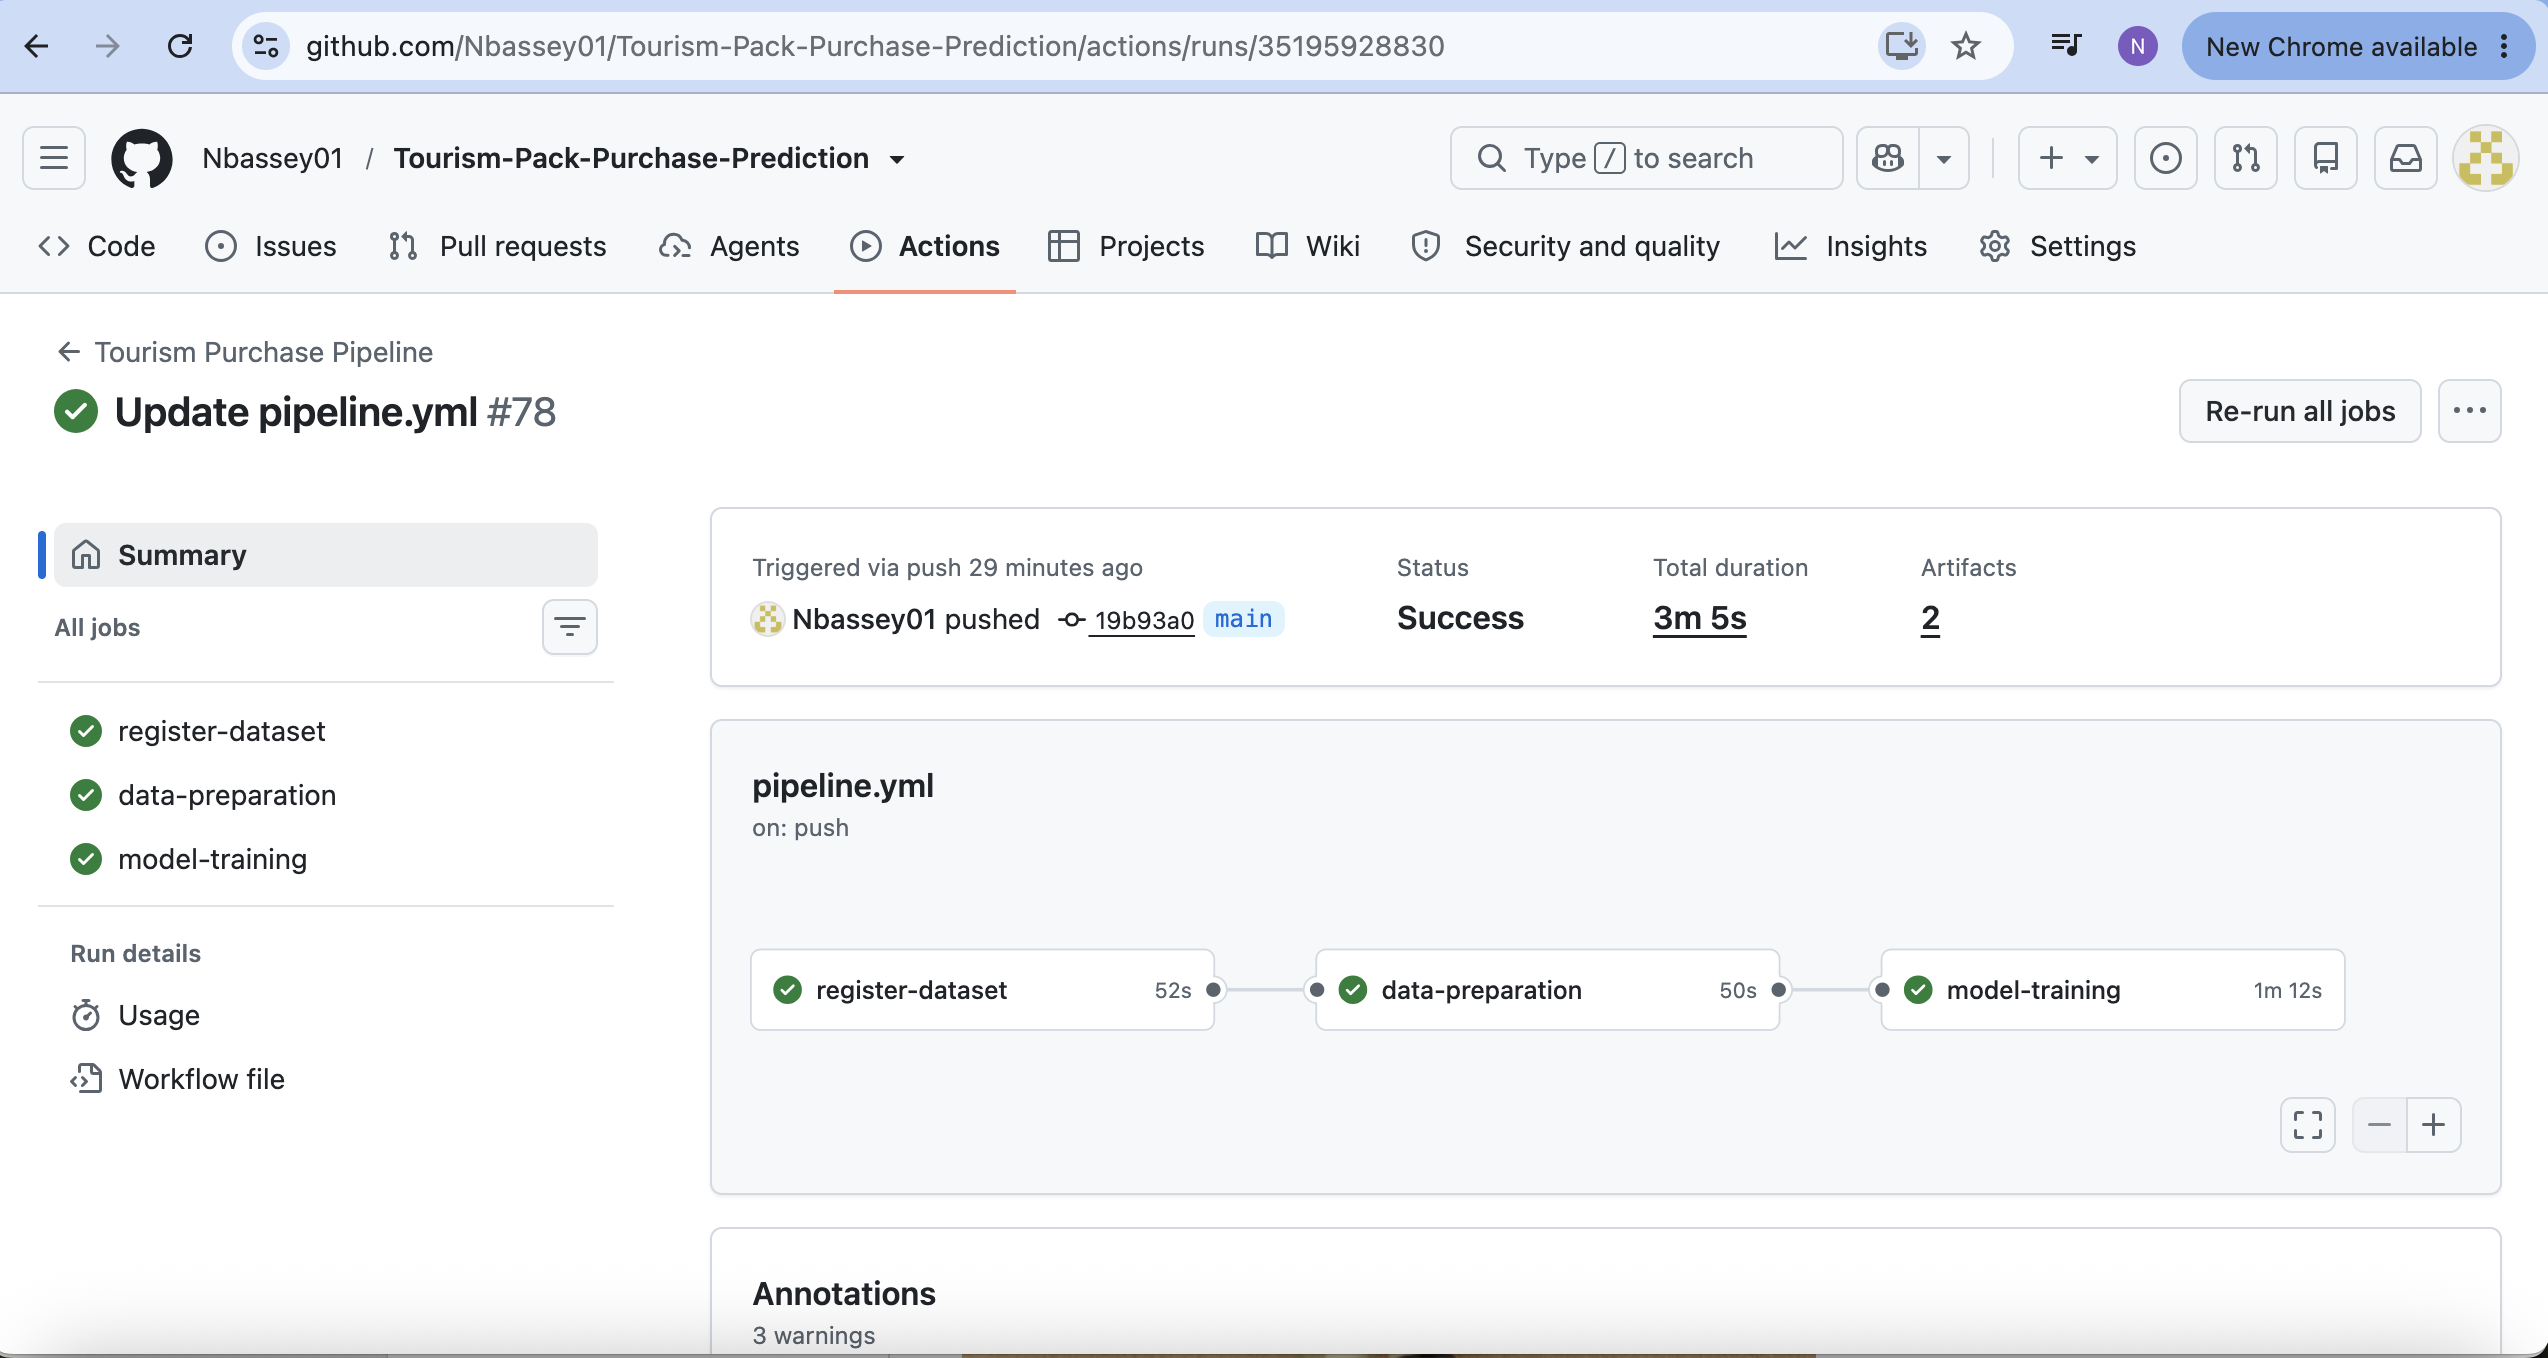

- Streamlit on Hugging Face (link to HF space, screenshot of Streamlit app)

https://tourism-pack-purchase-prediction.streamlit.app/

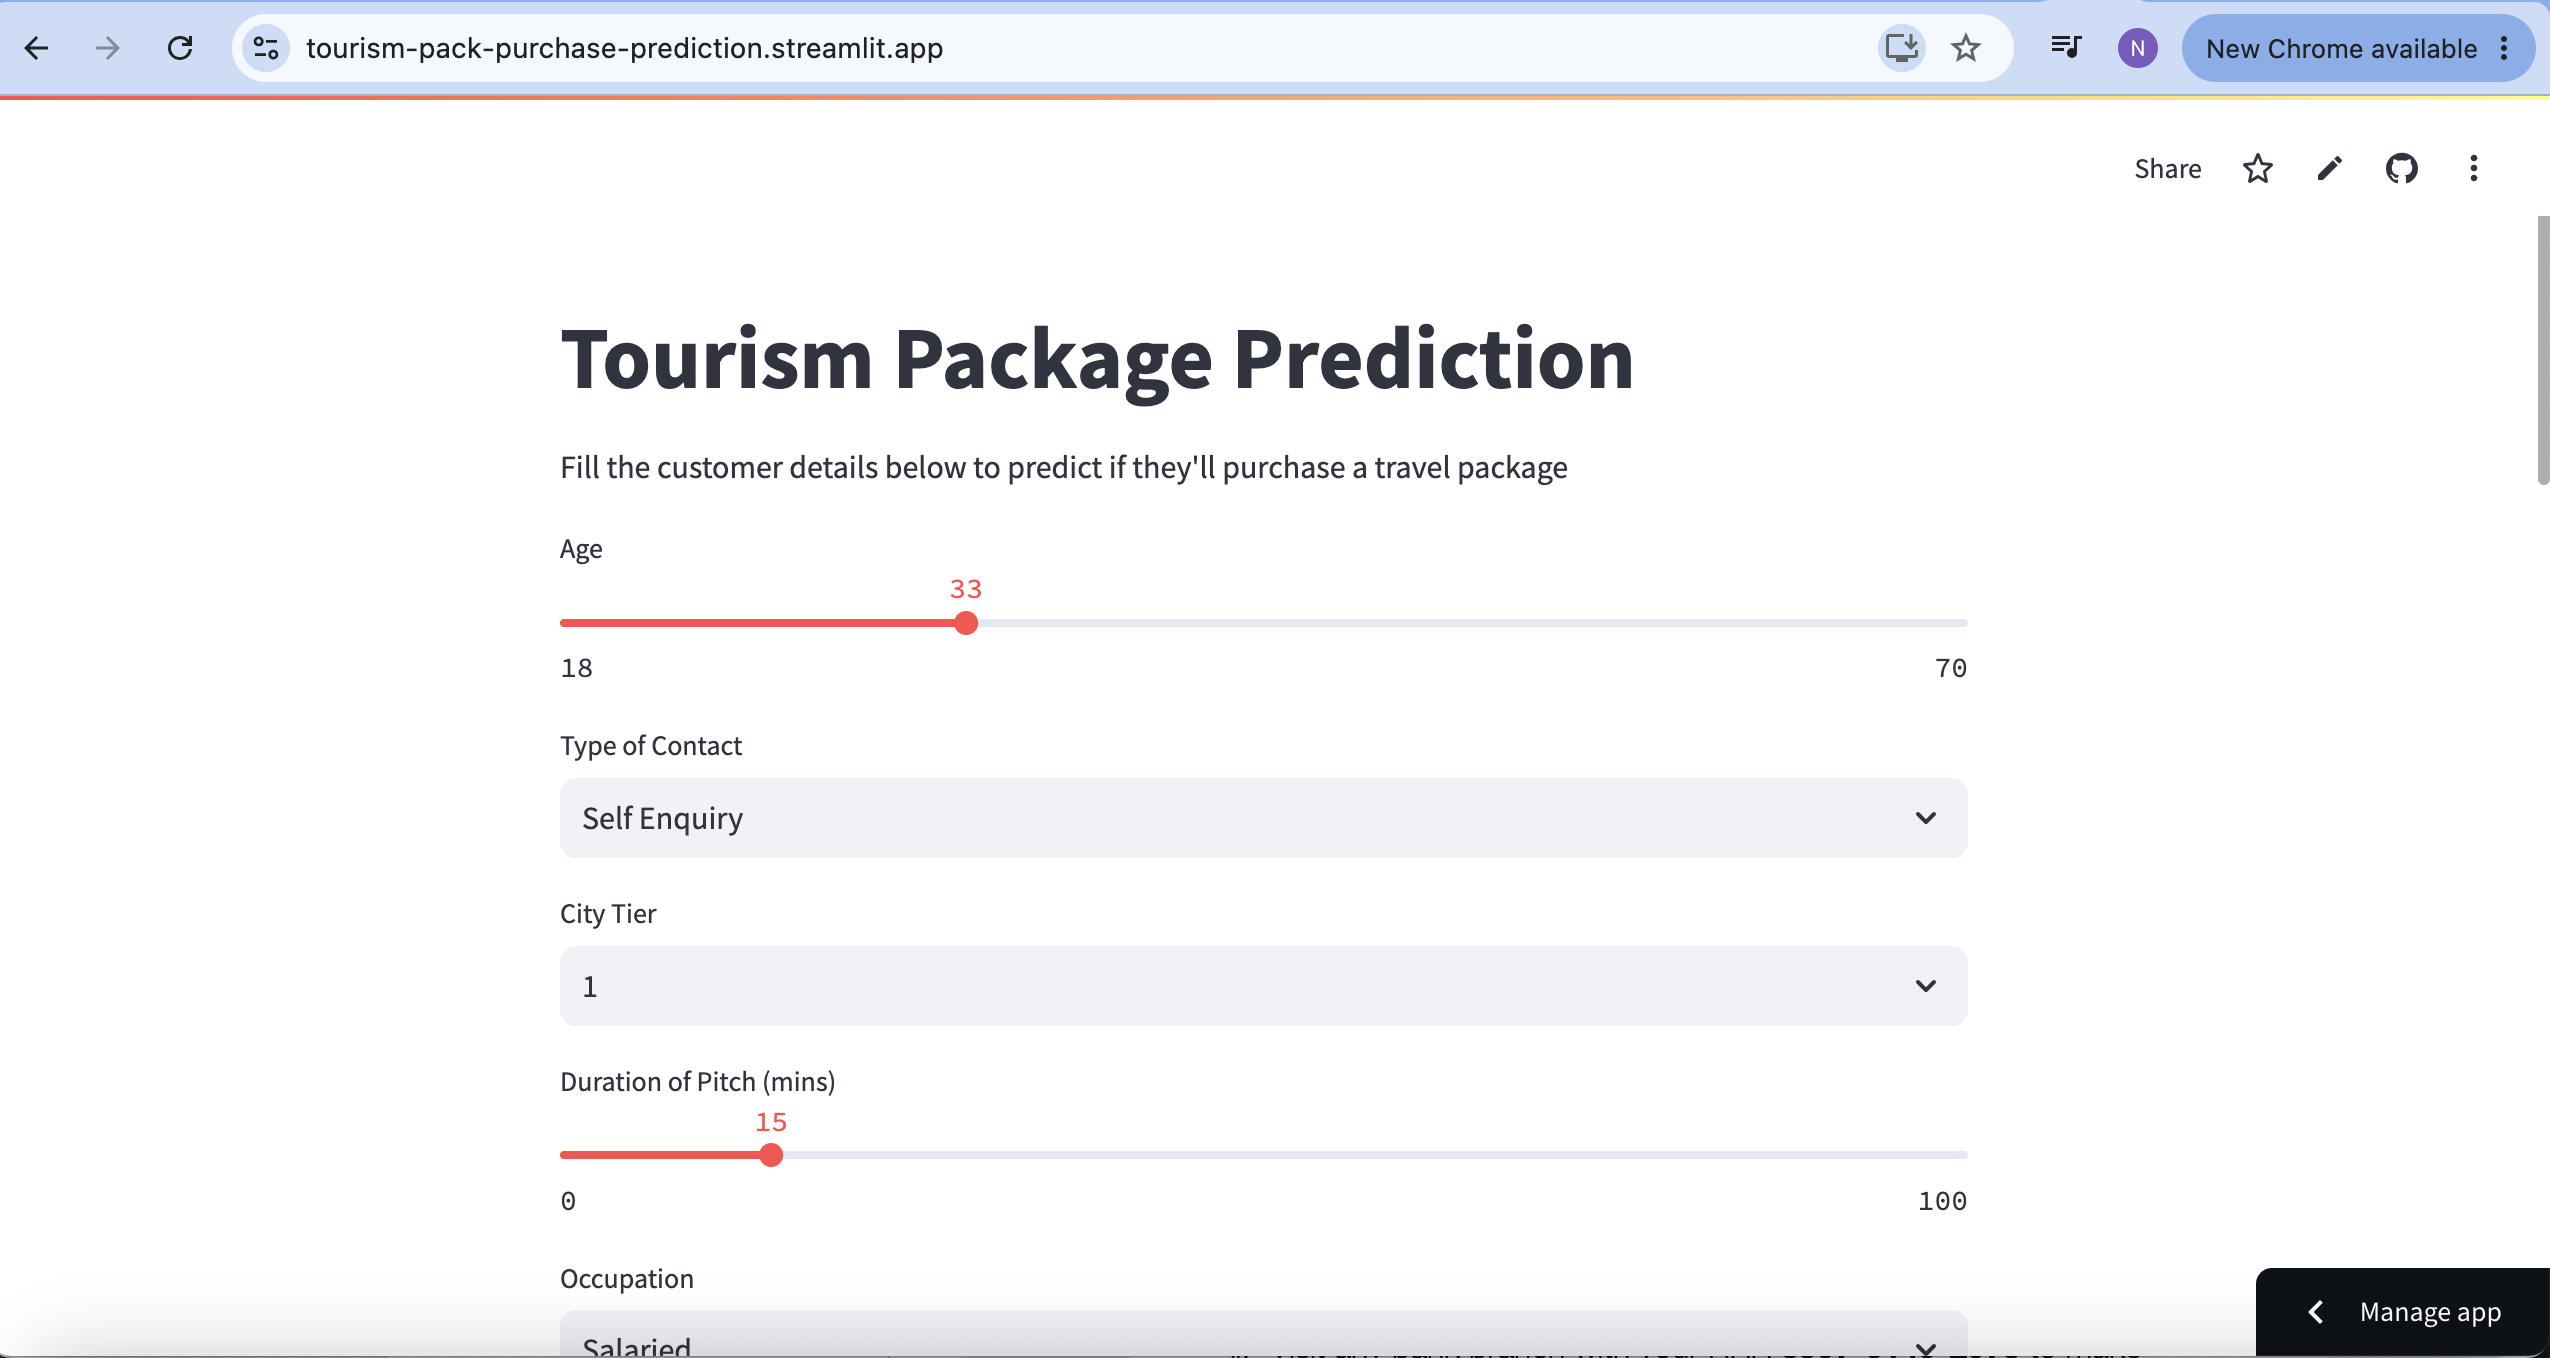

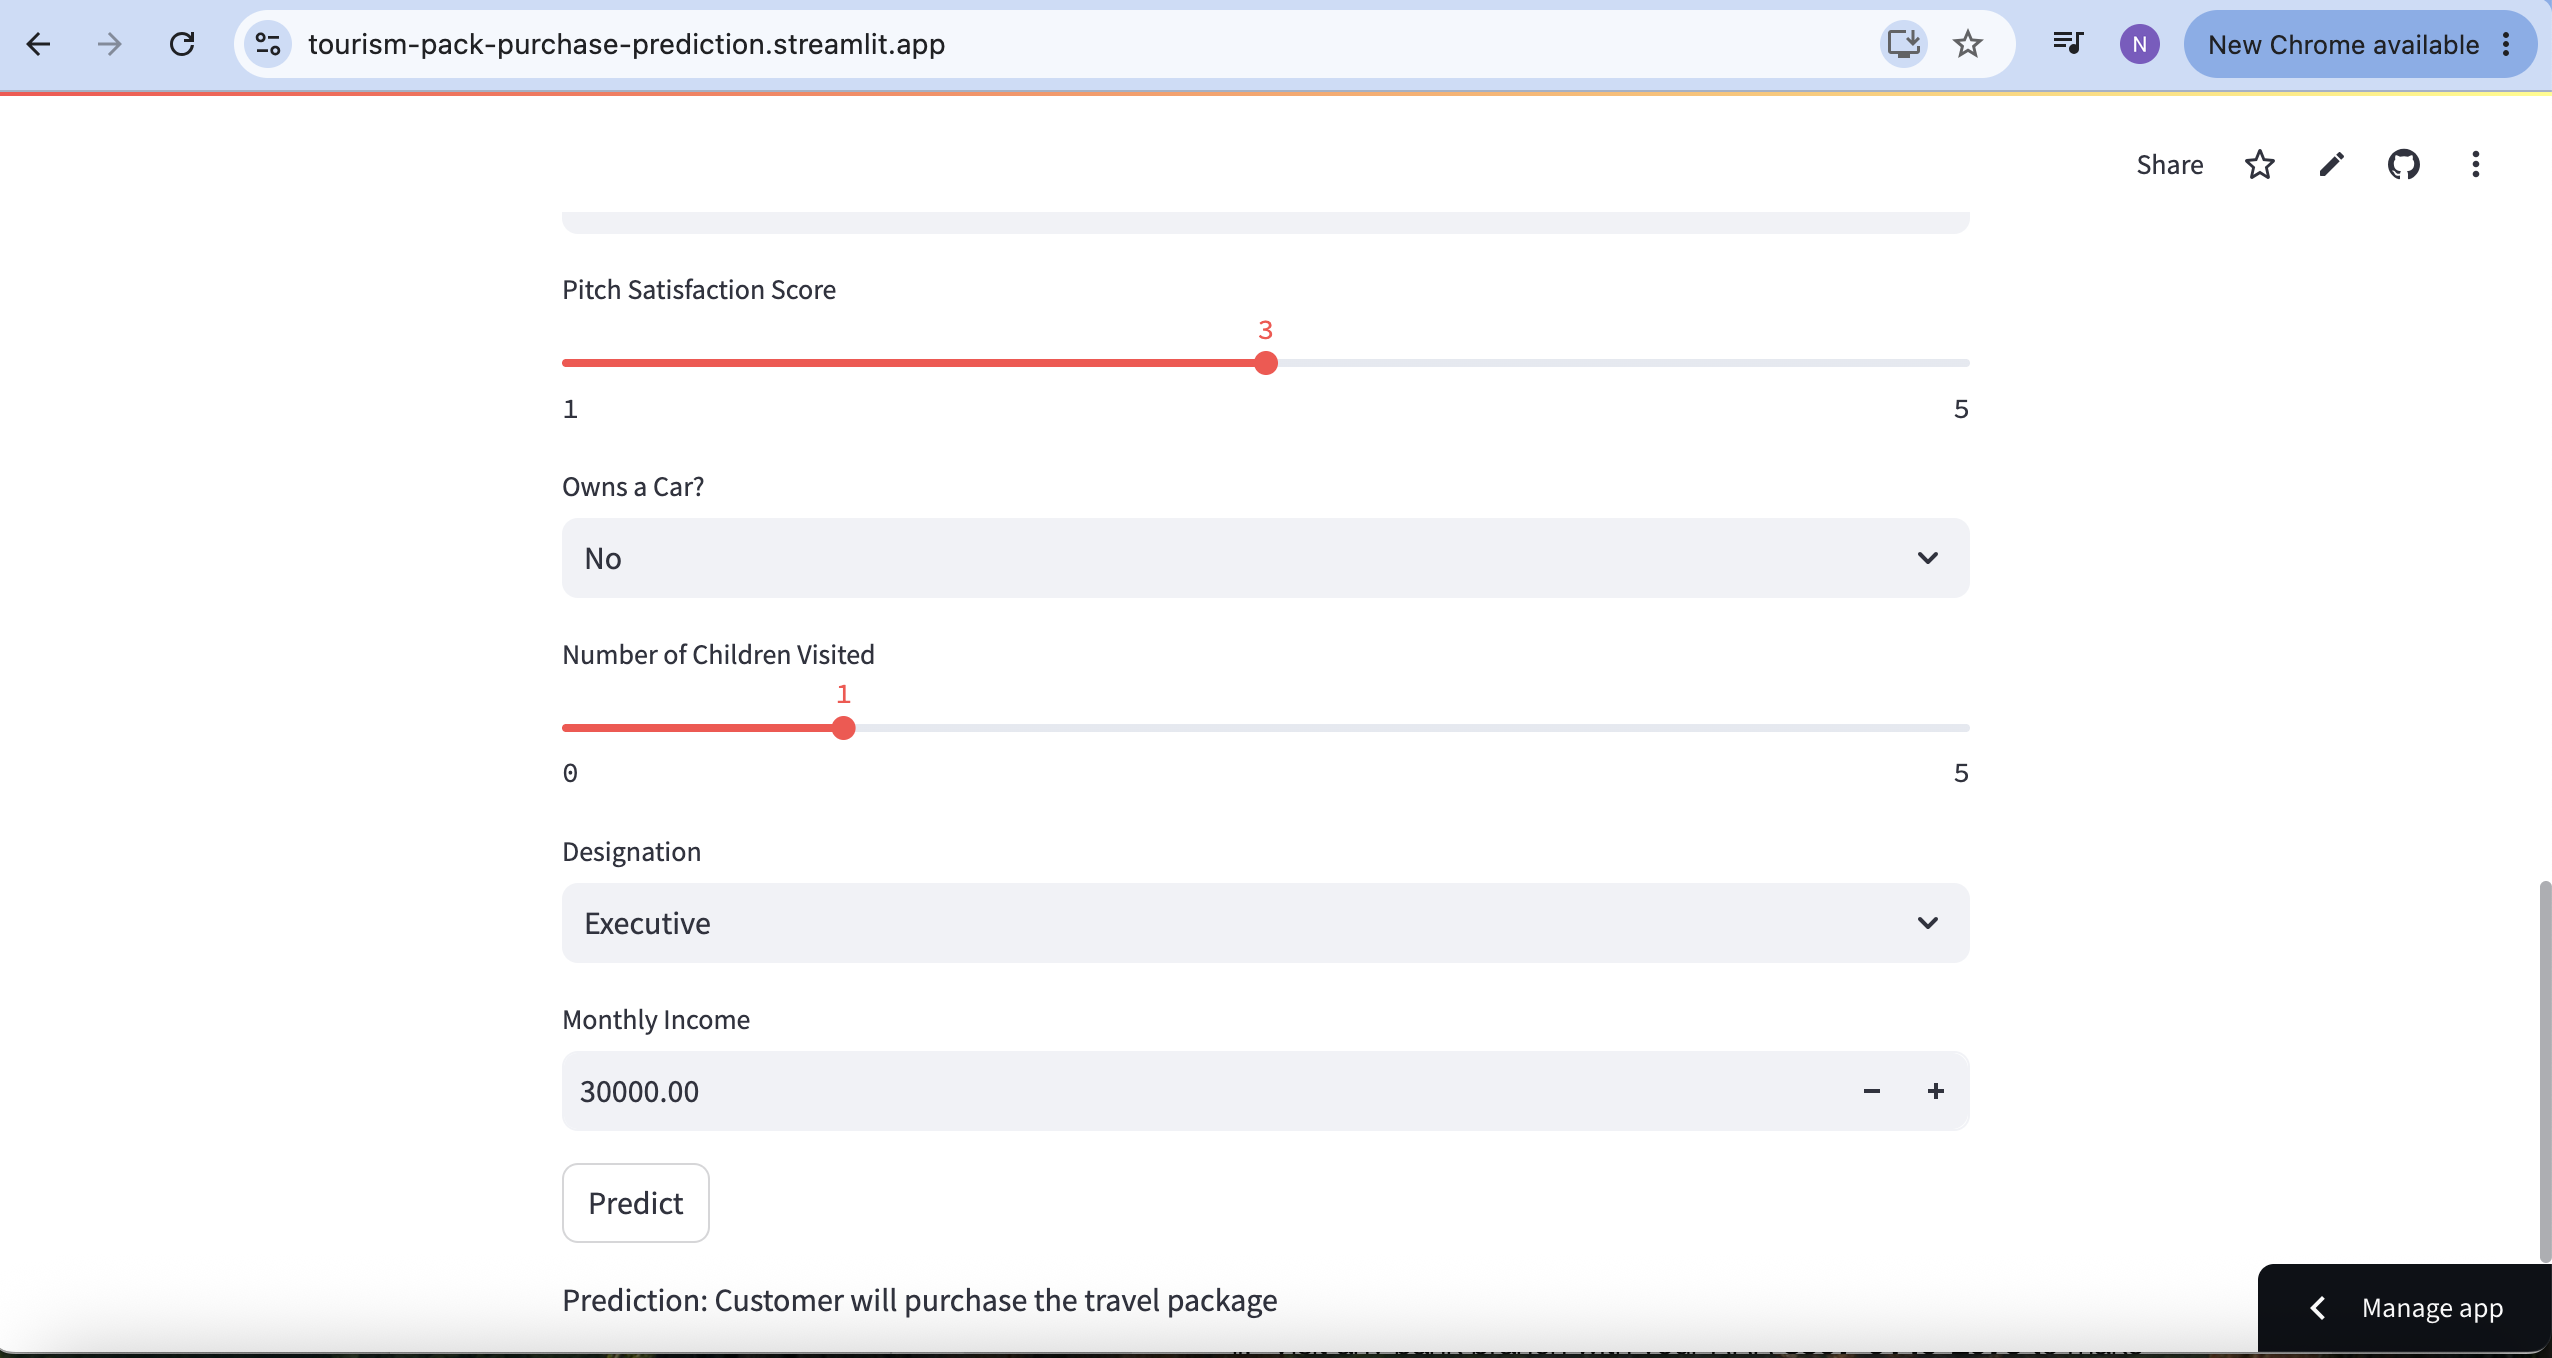

## **Recommendations**


* The whole aim of the project was to build a model that would predict if the new introduced tourism package from Visit Us Company would enjoy rapid patronage, we cant without firstly observing the datasets involved and cleaning them as well.
* Our model relied on xgboost base classifier with tunning parameters for effectiveness and accuracy which visit Us company can use the model.
* A structural workflow was build using the mflow to track our model against future changes after even after deployment.
* We performed exploratory analysis and saw a couple of correlations on columns which would form our basic of recommendations to visit us company.
* Type Of Contact column showed that self enquired customers had a large number of customers and purchased more package than those the company actualy invited which further points to referals. Visit us need to introduce referal bonuses to customers that refered others and also update thier publicity department for more invites and the invites to get to the customers.
*  Visit us company sales team can focus more on higher duration of pitch and increase followups to boost patronage to the new tourism package.
* Visit us company woud increase product purchase by targeting more Small Business Owners, Salaries earners, Tier1 and Tier3 category as these customers had large base of those who would buy packages and would buy the new packasge when launch.
* Monthly income had high correlation with Age which fall between 27 to 45yrs, which indicates that potentials customers are more in these category and the age range would explore the new package.
* Number of People visiting showed strong correlations with Number of children that accompanied thier guardian to visit us company. increase children number and get a gift from visit Us incentives would raise patronage of the new package as children would want thier parents to buy so they get gifts which would increase patronage of the new tourism package.
* Proper advert of other products aside Deluxe and Standard would increase sales of the new package, also Managers and Executives are those designate who purchased more so Visit Us would increase sales to other designate to enjoy patronage.



<font size=6 color="navyblue">Power Ahead!</font>
___